In [ ]:
import importlib.util
import sys

packages = {
    "numpy": "numpy==2.2.0",
    "pandas": "pandas==2.2.3",
    "sklearn": "scikit-learn==1.6.0",
    "matplotlib": "matplotlib==3.9.3",
    "tensorflow": "tensorflow==2.18.0",
    "seaborn": "seaborn==0.13.2",
    "pyarrow": "pyarrow",
    "requests": "requests",
}

for module_name, pip_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        !{sys.executable} -m pip install {pip_name}
    else:
        print(f"{module_name} is already installed")

In [3]:
import tensorflow as tf
print("tensorflow:", tf.__version__)

import pyarrow
print("pyarrow:", pyarrow.__version__)

import pandas as pd
print("pandas:", pd.__version__)

import sklearn
print("scikit-learn:", sklearn.__version__)

import matplotlib
print("matplotlib:", matplotlib.__version__)

import requests
print("requests:", requests.__version__)

tensorflow: 2.18.0
pyarrow: 23.0.1
pandas: 3.0.1
scikit-learn: 1.6.0
matplotlib: 3.9.3
requests: 2.32.3


In [4]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
import requests
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout

Create synthetic data for stock price


In [5]:
import numpy as np
import pandas as pd

# create a synthetic stock price dataset
np.random.seed(42)
data_length = 2000  # Adjust data length as needed
trend = np.linspace(100, 200, data_length)
noise = np.random.normal(0, 2, data_length)
synthetic_data = trend + noise

# Create a DataFrame and save as 'stock_prices.csv'
data = pd.DataFrame(synthetic_data, columns=['Close'])
data.to_csv('stock_prices.csv', index=False)
print("Synthetic stock_prices.csv created and loaded.")


Synthetic stock_prices.csv created and loaded.


What below code does: Take the stock prices, scale them, then build many examples where the model sees 100 previous prices and tries to predict the next one.<br>

Below code is not training a model yet. It is only preparing the stock price data so an LSTM or similar model can be trained on it.<br>

It basically, says if the input is this series X[i], what the output should be.

If prices are:  <br>
[1, 2, 3, 4, 5, 6]<br>
and time_step = 3, then:<br>
X[0] = [1, 2, 3], Y[0] = 4<br>
X[1] = [2, 3, 4], Y[1] = 5<br>
X[2] = [3, 4, 5], Y[2] = 6<br>

In [6]:
# Read the CSV file into a pandas DataFrame
data = pd.read_csv('stock_prices.csv') 

# Keep only the 'Close' column and convert it to a NumPy array
data = data[['Close']].values 

# Create a scaler that will map values into the range from 0 to 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler on the data and transform the data to normalized values
data = scaler.fit_transform(data)

# Define a function to turn the time-series data into input-output sequences for training
def create_dataset(data, time_step=1):
    # Create empty lists to store input sequences and target values
    X, Y = [], []

    # Loop through the data to build sequences of length time_step
    for i in range(len(data)-time_step-1):
        # Take a window of consecutive values as one input sample
        a = data[i:(i+time_step), 0]

        # Add the input sequence to X
        X.append(a)

        # Add the next value after the sequence to Y as the prediction target
        Y.append(data[i + time_step, 0])

    # Convert the lists into NumPy arrays and return them
    return np.array(X), np.array(Y)

# Set the number of past time steps the model will use to predict the next value
time_step = 100

# Create the training input sequences X and target values Y
X, Y = create_dataset(data, time_step)

# Reshape X into 3D form: [samples, time steps, features] for LSTM input
X = X.reshape(X.shape[0], X.shape[1], 1)

# Print the shape of X to verify the input format
print("Shape of X:", X.shape) 

# Print the shape of Y to verify the target format
print("Shape of Y:", Y.shape)

Shape of X: (1899, 100, 1)
Shape of Y: (1899,)


### Multi-head self-attention


In [8]:
class MultiHeadSelfAttention(Layer): 

    def __init__(self, embed_dim, num_heads=8): 
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads 
        self.projection_dim = embed_dim // num_heads 
        self.query_dense = Dense(embed_dim) 
        self.key_dense = Dense(embed_dim) 
        self.value_dense = Dense(embed_dim) 
        self.combine_heads = Dense(embed_dim) 


    def attention(self, query, key, value): 
        score = tf.matmul(query, key, transpose_b=True) 
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32) 
        scaled_score = score / tf.math.sqrt(dim_key) 
        weights = tf.nn.softmax(scaled_score, axis=-1) 
        output = tf.matmul(weights, value) 
        return output, weights 

    def split_heads(self, x, batch_size): 
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim)) 
        return tf.transpose(x, perm=[0, 2, 1, 3]) 

    # The call method applies the self-attention mechanism and combines the heads.
    def call(self, inputs): 
        batch_size = tf.shape(inputs)[0] 
        query = self.query_dense(inputs) 
        key = self.key_dense(inputs) 
        value = self.value_dense(inputs) 
        #  splits the input into multiple heads for parallel attention computation.
        query = self.split_heads(query, batch_size) 
        key = self.split_heads(key, batch_size) 
        value = self.split_heads(value, batch_size) 
        # computes the actual attention scores and weighted combination
        attention, _ = self.attention(query, key, value) 
        attention = tf.transpose(attention, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim)) 
        output = self.combine_heads(concat_attention)  # merges all heads back together
        return output 

 

Implement transformer block:<br>
TransformerBlock layer combines multi-head self-attention with a feed-forward neural network and normalization layers.

In [9]:
class TransformerBlock(Layer): 

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        # Dropout is used to prevent overfitting.
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 

    # The call method applies the self-attention, followed by the feedforward network
    #  with residual connections and layer normalization.
    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 

encoder layer:<br>
It has MultiHeadSelfAttention mechanism followed by a feedforward neural network.<br>
Both sub-layers have residual connections around them, and layer normalization is applied to the output of each sub-layer.<br>


In [10]:
class EncoderLayer(Layer): 

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(EncoderLayer, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 

 

    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 



Transformer encoder <br>
The TransformerEncoder is composed of multiple TransformerBlock layers, implementing the encoding part of the Transformer architecture.

In [11]:
import tensorflow as tf 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout 

class MultiHeadSelfAttention(Layer): 
    def __init__(self, embed_dim, num_heads=8): 
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads 
        self.projection_dim = embed_dim // num_heads 
        self.query_dense = Dense(embed_dim) 
        self.key_dense = Dense(embed_dim) 
        self.value_dense = Dense(embed_dim) 
        self.combine_heads = Dense(embed_dim) 
 

    def attention(self, query, key, value): 
        score = tf.matmul(query, key, transpose_b=True) 
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32) 
        scaled_score = score / tf.math.sqrt(dim_key) 
        weights = tf.nn.softmax(scaled_score, axis=-1) 
        output = tf.matmul(weights, value) 
        return output, weights 


    def split_heads(self, x, batch_size): 
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim)) 
        return tf.transpose(x, perm=[0, 2, 1, 3]) 


    def call(self, inputs): 
        batch_size = tf.shape(inputs)[0] 
        query = self.query_dense(inputs) 
        key = self.key_dense(inputs) 
        value = self.value_dense(inputs) 
        query = self.split_heads(query, batch_size) 
        key = self.split_heads(key, batch_size) 
        value = self.split_heads(value, batch_size) 
        attention, _ = self.attention(query, key, value) 
        attention = tf.transpose(attention, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim)) 
        output = self.combine_heads(concat_attention) 
        return output 

class TransformerBlock(Layer): 
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 
 

    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 

class TransformerEncoder(Layer): 
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerEncoder, self).__init__() 
        self.num_layers = num_layers 
        self.embed_dim = embed_dim 
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate) for _ in range(num_layers)] 
        self.dropout = Dropout(rate) 

    def call(self, inputs, training=False): 
        x = inputs 
        for i in range(self.num_layers): 
            x = self.enc_layers[i](x, training=training) 
        return x 

# Example usage 
embed_dim = 128 
num_heads = 8 
ff_dim = 512 
num_layers = 4 

transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim) 
inputs = tf.random.uniform((1, 100, embed_dim)) 
outputs = transformer_encoder(inputs, training=False)  # Use keyword argument for 'training' 
print(outputs.shape)  # Should print (1, 100, 128) 

(1, 100, 128)


Build and compile transformer model

In [13]:
# Define the necessary parameters 

embed_dim = 128 
num_heads = 8 
ff_dim = 512 
num_layers = 4 

# Define the Transformer Encoder 
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim) 

# Build the model 
input_shape = (X.shape[1], X.shape[2]) 
inputs = tf.keras.Input(shape=input_shape) 

# Project the inputs to the embed_dim 
x = tf.keras.layers.Dense(embed_dim)(inputs) 
encoder_outputs = transformer_encoder(x) 
flatten = tf.keras.layers.Flatten()(encoder_outputs) 
outputs = tf.keras.layers.Dense(1)(flatten) 
model = tf.keras.Model(inputs, outputs) 

# Compile the model 
model.compile(optimizer='adam', loss='mse') 

# Summary of the model 
model.summary() 


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 100, 128)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 100, 128)       │       793,088 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,145 (3.08 MB)

 Trainable params: 806,145 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

train the model

In [14]:
# Train the model
model.fit(X, Y, epochs=20, batch_size=32)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 414ms/step - loss: 4.9251
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 374ms/step - loss: 0.2003
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 437ms/step - loss: 0.1758
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 414ms/step - loss: 0.1382
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 443ms/step - loss: 0.1324
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 443ms/step - loss: 0.1641
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 436ms/step - loss: 0.1511
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 433ms/step - loss: 0.1447
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 409ms/step - loss: 0.1160
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 519ms/step - loss: 0.1303
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 439ms/step - loss: 0.1675
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 372ms/step - loss: 0.1113
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 364ms/step - loss: 0.1170
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 346ms/step - loss: 0.1105
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 

evaluate and make prediction

60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step


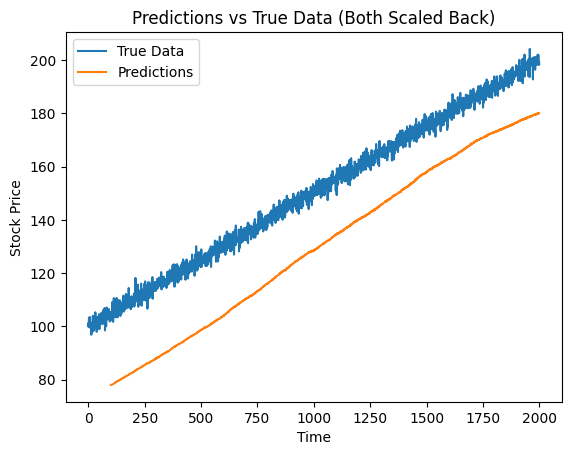

In [ ]:
# Make predictions 
predictions = model.predict(X) 
predictions = scaler.inverse_transform(predictions) 

# Prepare true values for comparison
true_values = scaler.inverse_transform(data.reshape(-1, 1))

# Plot the predictions vs true values
import matplotlib.pyplot as plt 

plt.plot(true_values, label='True Data') 
plt.plot(np.arange(time_step, time_step + len(predictions)), predictions, label='Predictions') 
plt.xlabel('Time') 
plt.ylabel('Stock Price') 
plt.legend() 
plt.title('Predictions vs True Data (Both Scaled Back)')
plt.show() 
